In [29]:
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os
import warnings
warnings.filterwarnings('ignore')

In [30]:
np.random.seed(42)
torch.manual_seed(42)

OUTPUT_DIR = './gan_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [31]:
def load_data():
    try:
        df = pd.read_csv('/kaggle/input/india-air-quality-data')
        no2_data = df['no2'].dropna().values
        print(f'Loaded {len(no2_data)} NO2 samples from file')
        return no2_data
    except:
        print('Generating synthetic NO2 data...')
        no2_data = np.random.lognormal(mean=3, sigma=0.8, size=5000)
        no2_data = np.clip(no2_data, 0, 200)
        return no2_data

def transform_data(x, roll_number):
    a_r = 0.5 * (roll_number % 7)
    b_r = 0.3 * ((roll_number % 5) + 1)
    z = x + a_r * np.sin(b_r * x)
    print(f'\nTransformation: z = x + {a_r:.4f} * sin({b_r:.4f} * x)')
    return z, a_r, b_r

In [32]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

In [33]:
def train_gan(z_real, noise_dim=100, epochs=10000, batch_size=128, lr=0.0002):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Training on: {device}')
    
    z_real = z_real.reshape(-1, 1).astype(np.float32)
    scaler = StandardScaler()
    z_normalized = scaler.fit_transform(z_real)
    z_tensor = torch.FloatTensor(z_normalized).to(device)
    dataset = TensorDataset(z_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    generator = Generator(noise_dim=noise_dim).to(device)
    discriminator = Discriminator().to(device)
    
    criterion = nn.BCELoss()
    optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    
    g_losses = []
    d_losses = []
    
    print(f'Starting training for {epochs} epochs...')
    
    for epoch in range(epochs):
        epoch_g_loss = 0
        epoch_d_loss = 0
        n_batches = 0
        
        for batch_idx, (real_data,) in enumerate(dataloader):
            batch_size_actual = real_data.size(0)
            real_labels = torch.ones(batch_size_actual, 1).to(device)
            fake_labels = torch.zeros(batch_size_actual, 1).to(device)
            
            optimizer_d.zero_grad()
            real_output = discriminator(real_data)
            d_loss_real = criterion(real_output, real_labels)
            
            noise = torch.randn(batch_size_actual, noise_dim).to(device)
            fake_data = generator(noise)
            fake_output = discriminator(fake_data.detach())
            d_loss_fake = criterion(fake_output, fake_labels)
            
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_d.step()
            
            optimizer_g.zero_grad()
            noise = torch.randn(batch_size_actual, noise_dim).to(device)
            fake_data = generator(noise)
            fake_output = discriminator(fake_data)
            g_loss = criterion(fake_output, real_labels)
            g_loss.backward()
            optimizer_g.step()
            
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            n_batches += 1
        
        avg_g_loss = epoch_g_loss / n_batches
        avg_d_loss = epoch_d_loss / n_batches
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        
        if (epoch + 1) % 500 == 0:
            print(f'Epoch [{epoch+1}/{epochs}] D Loss: {avg_d_loss:.4f} G Loss: {avg_g_loss:.4f}')
    
    print('Training completed!')
    return generator, discriminator, scaler, g_losses, d_losses

In [34]:
def generate_samples(generator, scaler, n_samples=10000, noise_dim=100):
    device = next(generator.parameters()).device
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(n_samples, noise_dim).to(device)
        fake_samples = generator(noise).cpu().numpy()
    fake_samples = scaler.inverse_transform(fake_samples).flatten()
    return fake_samples

def estimate_pdf_kde(samples):
    kde = stats.gaussian_kde(samples, bw_method='scott')
    x_eval = np.linspace(samples.min(), samples.max(), 1000)
    pdf_values = kde(x_eval)
    return x_eval, pdf_values

In [35]:
def plot_transformation(x_original, z_transformed, a_r, b_r):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].hist(x_original, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_xlabel('NO2 Concentration (x)')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Original NO2 Distribution')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(z_transformed, bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
    axes[1].set_xlabel('Transformed Value (z)')
    axes[1].set_ylabel('Density')
    axes[1].set_title(f'Transformed Distribution\nz = x + {a_r:.4f}*sin({b_r:.4f}*x)')
    axes[1].grid(True, alpha=0.3)
    
    x_range = np.linspace(x_original.min(), x_original.max(), 1000)
    z_range = x_range + a_r * np.sin(b_r * x_range)
    axes[2].plot(x_range, z_range, 'r-', linewidth=2)
    axes[2].set_xlabel('Original NO2 (x)')
    axes[2].set_ylabel('Transformed Value (z)')
    axes[2].set_title('Transformation Function')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'transformation.png'), dpi=300, bbox_inches='tight')
    plt.show()

def plot_training_progress(g_losses, d_losses):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    epochs = range(1, len(g_losses) + 1)
    ax.plot(epochs, g_losses, label='Generator Loss', color='blue', alpha=0.7)
    ax.plot(epochs, d_losses, label='Discriminator Loss', color='red', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('GAN Training Progress')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_progress.png'), dpi=300, bbox_inches='tight')
    plt.show()

def plot_pdf_comparison(z_real, z_fake):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(z_real, bins=50, density=True, alpha=0.5, label='Real Data', color='blue', edgecolor='black')
    axes[0].hist(z_fake, bins=50, density=True, alpha=0.5, label='Generated Data', color='red', edgecolor='black')
    axes[0].set_xlabel('z')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Distribution Comparison (Histogram)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    x_real, pdf_real = estimate_pdf_kde(z_real)
    x_fake, pdf_fake = estimate_pdf_kde(z_fake)
    
    axes[1].plot(x_real, pdf_real, label='Real Data (KDE)', color='blue', linewidth=2)
    axes[1].plot(x_fake, pdf_fake, label='Generated Data (KDE)', color='red', linewidth=2, linestyle='--')
    axes[1].fill_between(x_real, pdf_real, alpha=0.3, color='blue')
    axes[1].fill_between(x_fake, pdf_fake, alpha=0.3, color='red')
    axes[1].set_xlabel('z')
    axes[1].set_ylabel('Probability Density')
    axes[1].set_title('PDF Estimation using KDE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'pdf_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()

def plot_qq_plot(z_real, z_fake):
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    
    n_points = min(len(z_real), len(z_fake))
    quantiles = np.linspace(0, 1, n_points)
    real_quantiles = np.quantile(z_real, quantiles)
    fake_quantiles = np.quantile(z_fake, quantiles)
    
    ax.scatter(real_quantiles, fake_quantiles, alpha=0.5, s=10)
    min_val = min(real_quantiles.min(), fake_quantiles.min())
    max_val = max(real_quantiles.max(), fake_quantiles.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Match')
    
    ax.set_xlabel('Real Data Quantiles')
    ax.set_ylabel('Generated Data Quantiles')
    ax.set_title('Q-Q Plot: Real vs Generated Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'qq_plot.png'), dpi=300, bbox_inches='tight')
    plt.show()

In [36]:
ROLL_NUMBER = 102483083
NOISE_DIM = 100
EPOCHS = 10000
BATCH_SIZE = 128
LEARNING_RATE = 0.0002
N_SAMPLES = 10000

Learning Probability Density Functions using GANs

Step 1: Loading and transforming data...
Generating synthetic NO2 data...

Transformation: z = x + 1.5000 * sin(1.2000 * x)


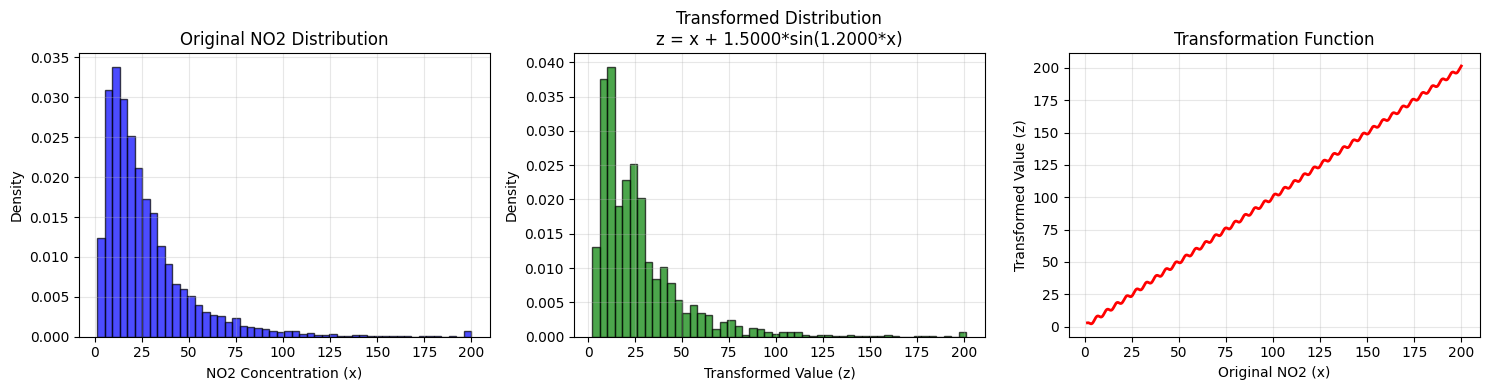

In [37]:
print('='*70)
print('Learning Probability Density Functions using GANs')
print('='*70)

print('\nStep 1: Loading and transforming data...')
x_original = load_data()
z_transformed, a_r, b_r = transform_data(x_original, ROLL_NUMBER)

plot_transformation(x_original, z_transformed, a_r, b_r)

In [38]:
from tqdm import tqdm

def train_gan(z_real, noise_dim=100, epochs=10000, batch_size=128, lr=0.0002):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Training on: {device}')
    
    z_real = z_real.reshape(-1, 1).astype(np.float32)
    scaler = StandardScaler()
    z_normalized = scaler.fit_transform(z_real)
    z_tensor = torch.FloatTensor(z_normalized).to(device)
    dataset = TensorDataset(z_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    generator = Generator(noise_dim=noise_dim).to(device)
    discriminator = Discriminator().to(device)
    
    criterion = nn.BCELoss()
    optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    
    g_losses = []
    d_losses = []
    
    progress_bar = tqdm(range(epochs), desc='Training GAN')
    
    for epoch in progress_bar:
        epoch_g_loss = 0
        epoch_d_loss = 0
        n_batches = 0
        
        for batch_idx, (real_data,) in enumerate(dataloader):
            batch_size_actual = real_data.size(0)
            real_labels = torch.ones(batch_size_actual, 1).to(device)
            fake_labels = torch.zeros(batch_size_actual, 1).to(device)
            
            optimizer_d.zero_grad()
            real_output = discriminator(real_data)
            d_loss_real = criterion(real_output, real_labels)
            
            noise = torch.randn(batch_size_actual, noise_dim).to(device)
            fake_data = generator(noise)
            fake_output = discriminator(fake_data.detach())
            d_loss_fake = criterion(fake_output, fake_labels)
            
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_d.step()
            
            optimizer_g.zero_grad()
            noise = torch.randn(batch_size_actual, noise_dim).to(device)
            fake_data = generator(noise)
            fake_output = discriminator(fake_data)
            g_loss = criterion(fake_output, real_labels)
            g_loss.backward()
            optimizer_g.step()
            
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            n_batches += 1
        
        avg_g_loss = epoch_g_loss / n_batches
        avg_d_loss = epoch_d_loss / n_batches
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        
        progress_bar.set_postfix({'D_Loss': f'{avg_d_loss:.4f}', 'G_Loss': f'{avg_g_loss:.4f}'})
    
    print('Training completed!')
    return generator, discriminator, scaler, g_losses, d_losses


Step 2: Training GAN...
Training on: cuda


Training GAN: 100%|██████████| 10000/10000 [50:29<00:00,  3.30it/s, D_Loss=1.2611, G_Loss=0.8515]


Training completed!


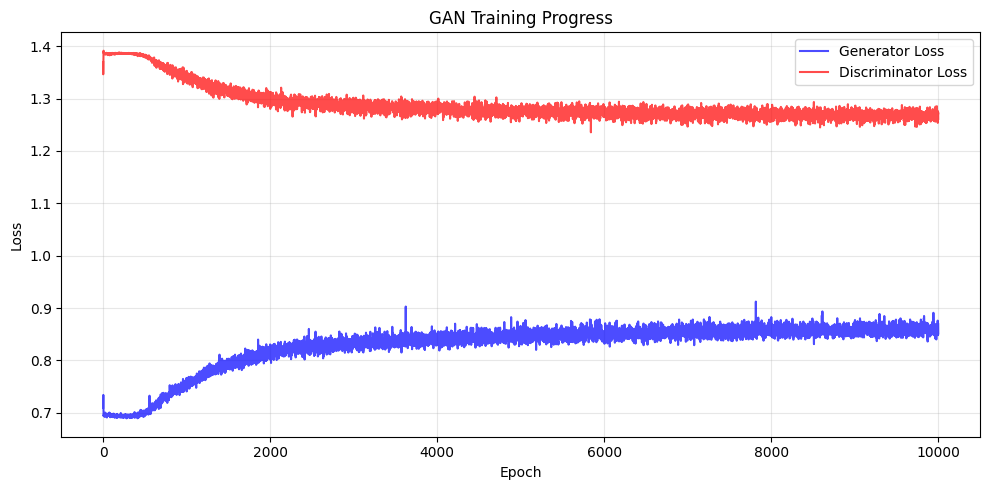

In [39]:
print('\nStep 2: Training GAN...')
generator, discriminator, scaler, g_losses, d_losses = train_gan(
    z_transformed, 
    noise_dim=NOISE_DIM,
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    lr=LEARNING_RATE
)

plot_training_progress(g_losses, d_losses)


Step 3: Generating samples and estimating PDF...


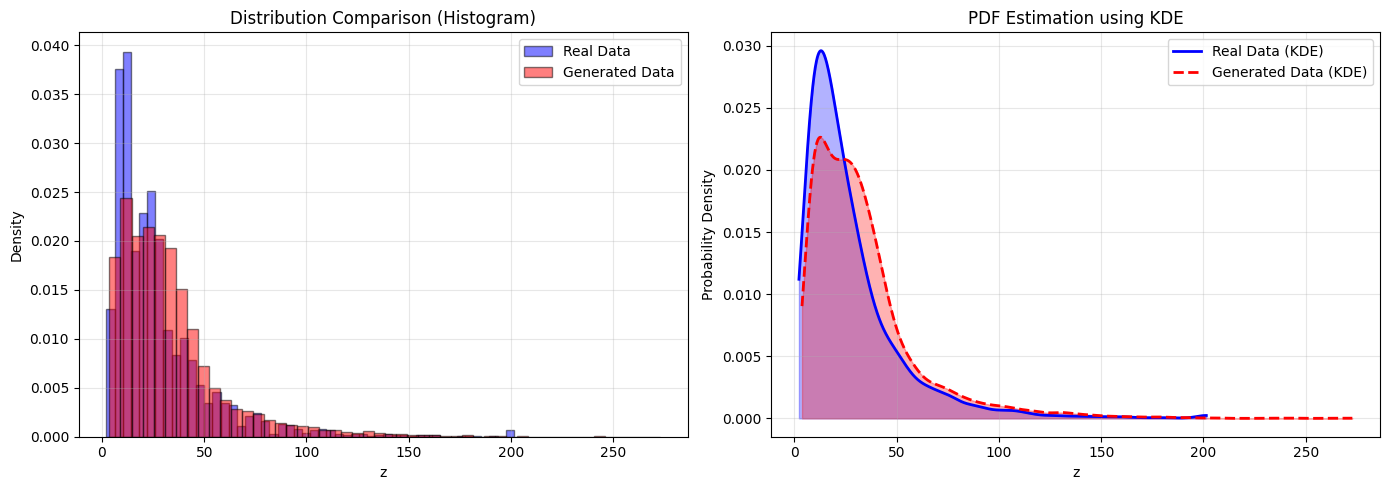

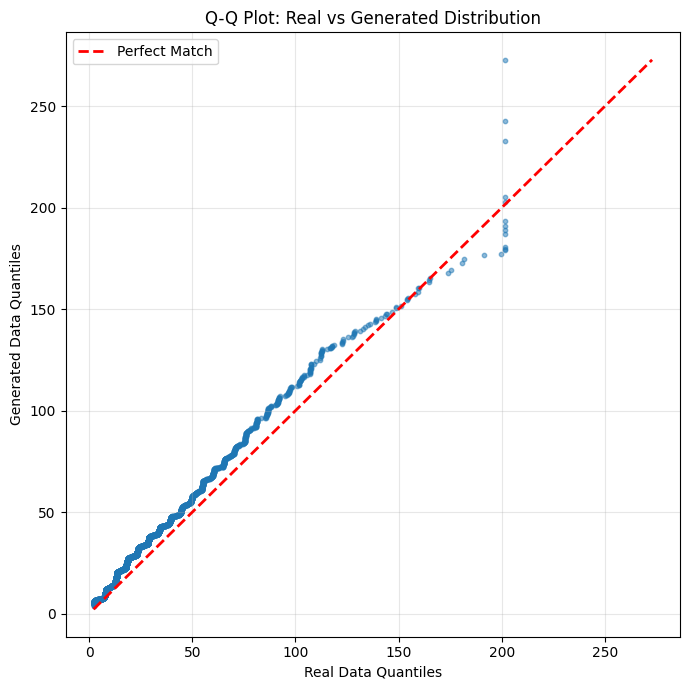

In [40]:
print('\nStep 3: Generating samples and estimating PDF...')
z_fake = generate_samples(generator, scaler, n_samples=N_SAMPLES, noise_dim=NOISE_DIM)

plot_pdf_comparison(z_transformed, z_fake)
plot_qq_plot(z_transformed, z_fake)

In [41]:
ks_statistic, ks_pvalue = stats.ks_2samp(z_transformed, z_fake)

print('\n' + '='*70)
print('Results')
print('='*70)
print(f'\nReal Data:')
print(f'  Mean: {z_transformed.mean():.4f}')
print(f'  Std:  {z_transformed.std():.4f}')
print(f'  Min:  {z_transformed.min():.4f}')
print(f'  Max:  {z_transformed.max():.4f}')

print(f'\nGenerated Data:')
print(f'  Mean: {z_fake.mean():.4f}')
print(f'  Std:  {z_fake.std():.4f}')
print(f'  Min:  {z_fake.min():.4f}')
print(f'  Max:  {z_fake.max():.4f}')

print(f'\nKolmogorov-Smirnov Test:')
print(f'  Statistic: {ks_statistic:.4f}')
print(f'  P-value:   {ks_pvalue:.4f}')

if ks_pvalue > 0.05:
    print('  Result: Distributions are statistically similar ✓')
else:
    print('  Result: Distributions show some differences')

print(f'\nAll outputs saved to: {OUTPUT_DIR}/')
print('='*70)


Results

Real Data:
  Mean: 27.5228
  Std:  24.8603
  Min:  2.1889
  Max:  201.4182

Generated Data:
  Mean: 33.2983
  Std:  26.4985
  Min:  3.6770
  Max:  272.8354

Kolmogorov-Smirnov Test:
  Statistic: 0.1792
  P-value:   0.0000
  Result: Distributions show some differences

All outputs saved to: ./gan_outputs/
